In [2]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Dropout, Flatten
from keras.datasets import mnist
import numpy as np
import cv2
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.utils import shuffle

In [3]:
keys = {'stop': 0, 'forward': 1, 'left': 2, 'right': 3, 'no_entry': 4, 'dead_end': 5}

In [9]:
stop_images_path = '/home/taher/projects/Traffic-Sign-Detection/dataset/stop'
turn_right_path = '/home/taher/projects/Traffic-Sign-Detection/dataset/turnright'
turn_left_path = '/home/taher/projects/Traffic-Sign-Detection/dataset/turnleft'
no_entry_path = '/home/taher/projects/Traffic-Sign-Detection/dataset/noentry'
dead_end_path = '/home/taher/projects/Traffic-Sign-Detection/dataset/deadend'

stop_images_list = os.listdir(stop_images_path)
turn_right_list = os.listdir(turn_right_path)
turn_left_list = os.listdir(turn_left_path)
no_entry_list = os.listdir(no_entry_path)
dead_end_list = os.listdir(dead_end_path)

pictures = []
ys = []

# stop data
for image_name in stop_images_list:
    img = cv2.imread(f'{stop_images_path}/{image_name}')
    img = cv2.resize(img, (128, 128))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pictures.append(img)
    ys.append([1.0, 0, 0, 0, 0, 0])
    

# turn right data
for image_name in turn_right_list:
    img = cv2.imread(f'{turn_right_path}/{image_name}')
    img = cv2.resize(img, (128, 128))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pictures.append(img)
    ys.append([0, 0, 0, 1.0, 0, 0])
    

# turn left data
for image_name in turn_left_list:
    img = cv2.imread(f'{turn_left_path}/{image_name}')
    img = cv2.resize(img, (128, 128))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pictures.append(img)
    ys.append([0, 0, 1.0, 0, 0, 0])
    
for image_name in turn_right_list:
    img = cv2.imread(f'{turn_right_path}/{image_name}')
    img = cv2.resize(img, (128, 128))
    img = cv2.rotate(img, cv2.ROTATE_180)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pictures.append(img)
    ys.append([0, 0, 1.0, 0, 0, 0])
    
    
# forward data
for image_name in turn_left_list:
    img = cv2.imread(f'{turn_left_path}/{image_name}')
    img = cv2.resize(img, (128, 128))
    img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pictures.append(img)
    ys.append([0, 1.0, 0, 0, 0, 0])
    
for image_name in turn_right_list:
    img = cv2.imread(f'{turn_right_path}/{image_name}')
    img = cv2.resize(img, (128, 128))
    img = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pictures.append(img)
    ys.append([0, 1.0, 0, 0, 0, 0])
    
# no entry data
for image_name in no_entry_list:
    img = cv2.imread(f'{no_entry_path}/{image_name}')
    img = cv2.resize(img, (128, 128))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pictures.append(img)
    ys.append([0, 0, 0, 0, 1.0, 0])
    
# dead end data
for image_name in dead_end_list:
    img = cv2.imread(f'{dead_end_path}/{image_name}')
    img = cv2.resize(img, (128, 128))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pictures.append(img)
    ys.append([0, 0, 0, 0, 0, 1.0])


In [10]:
pictures = np.array(pictures)
ys = np.array(ys)

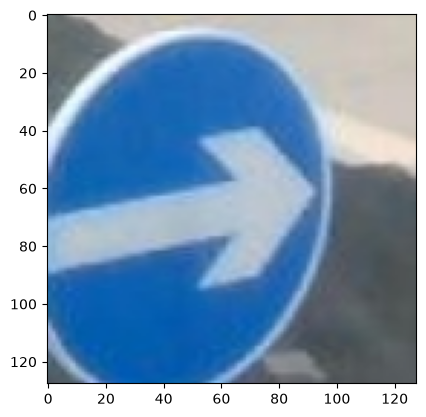

In [12]:
plt.imshow(pictures[1010])

In [13]:
pictures, ys = shuffle(pictures, ys, random_state=42)

pictures = pictures.astype(np.float32) / 255.0

x_train, x_test, y_train, y_test = train_test_split(pictures, ys, test_size=0.12)

In [14]:
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(128, 128, 3), padding='same'),
    MaxPool2D((2, 2)), 
    
    Conv2D(32, (3, 3), activation='relu', padding='same'), 
    MaxPool2D((2, 2)), 
    Dropout(0.25), 
    
    Conv2D(64, (3, 3), activation='relu', padding='same'), 
    MaxPool2D((2, 2)), 
    
    Flatten(), 
    
    Dense(64, activation='relu'), 
    Dropout(0.25), 
    
    Dense(6, activation='softmax')
])

/home/taher/projects/traffic_sign/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1781767198.338107   16159 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [15]:
model.compile('adam', 'categorical_crossentropy', metrics=['accuracy'])

In [16]:
model.fit(x_train ,y_train, batch_size=18, epochs=10)

Epoch 1/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 30s 90ms/step - accuracy: 0.9098 - loss: 0.2318
Epoch 2/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 28s 87ms/step - accuracy: 0.9921 - loss: 0.0266
Epoch 3/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 28s 88ms/step - accuracy: 0.9932 - loss: 0.0201
Epoch 4/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 28s 87ms/step - accuracy: 0.9855 - loss: 0.0487
Epoch 5/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 28s 88ms/step - accuracy: 0.9954 - loss: 0.0160
Epoch 6/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 28s 88ms/step - accuracy: 0.9972 - loss: 0.0103
Epoch 7/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 28s 87ms/step - accuracy: 0.9972 - loss: 0.0062
Epoch 8/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 28s 87ms/step - accuracy: 0.9960 - loss: 0.0117
Epoch 9/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 28s 88ms/step - accuracy: 0.9975 - loss: 0.0106
Epoch 10/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 28s 88ms/step - accuracy: 0.9984 - loss: 0.0061


In [17]:
model.save('traffic_sign.h5')

In [19]:
num = 84

pred = list(model.predict(x_test)[num])
print(pred.index(max(pred)))
y_test[num]
# plt.imshow()

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
5


array([0., 0., 0., 0., 0., 1.])